<a href="https://colab.research.google.com/github/Jih00nJung/assignment_list/blob/main/seriesStockTFT_fi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Demand forecasting with the Temporal Fusion Transformer

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install pytorch-forecasting
!pip install lightning
!pip install optuna
!pip install plt
!pip install torchmetrics
!pip install pytorch_optimizer
!pip install optuna-integration[pytorch_lightning]

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 399.8/399.8 kB 39.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.6/853.6 kB 61.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.8/159.8 kB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 70.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 41.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 30.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.0/71.0 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 287.4/287.4 kB 28.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.2/103.2 kB 10.4 MB/s eta 0:00:00


In [3]:
import warnings

import plt

warnings.filterwarnings("ignore")  # avoid printing out absolute paths

import lightning.pytorch as pl
from lightning.pytorch.callbacks import EarlyStopping, LearningRateMonitor
from lightning.pytorch.loggers import TensorBoardLogger
import numpy as np

from pytorch_forecasting import Baseline, TemporalFusionTransformer, TimeSeriesDataSet
from pytorch_forecasting.data import GroupNormalizer
from pytorch_forecasting.metrics import MAE, SMAPE, QuantileLoss

In [4]:
sector_name = "ITAndSemiconductor"
target_symbol = "SK하이닉스"

Load data
시계열 데이터를 pandas 데이터프레임으로 변환하는 과정이 필요함 하지만 예시 데이터셋은 이 형식임
특정 대리점에서 판매되는 제품별 판매량 6개월간 예측
약 21,000개의 월별 판매 기록이 있으며, 판매 가격, 대리점 위치, 공휴일 등의 특별일, 전체 산업 판매량 등의 정보

In [5]:
import pandas as pd
import numpy as np
import os
import glob
import unicodedata # Import unicodedata

file_paths = glob.glob(f"/content/drive/MyDrive/Colab Notebooks/industries/{sector_name}/*.csv")
all_data = []

# 데이터 라벨 적용 -> 병합 -> pd 변환
for file in file_paths:
    df = pd.read_csv(file)
    symbol = os.path.basename(file).replace('.csv', '')
    symbol = unicodedata.normalize('NFC', symbol) # Normalize symbol from file name
    df['Symbol'] = symbol
    all_data.append(df)

combined_df = pd.concat(all_data, ignore_index=True)

# Also normalize the Symbol column in combined_df to ensure consistency
combined_df['Symbol'] = combined_df['Symbol'].apply(lambda x: unicodedata.normalize('NFC', x))

combined_df['Date'] = pd.to_datetime(combined_df['Date'])

uq_symbols = combined_df['Symbol'].unique()
uq_dates = combined_df['Date'].unique()

multi_index = pd.MultiIndex.from_product([uq_symbols, uq_dates], names=['Symbol', 'Date'])
grid_df = pd.DataFrame(index=multi_index).reset_index()

# 날짜 결측치 left outer join
combined_df = pd.merge(grid_df, combined_df, on=['Symbol', 'Date'], how='left')
combined_df = combined_df.sort_values(by=['Symbol', 'Date'])

combined_df['is_filled'] = combined_df['Close'].isna().astype(str)

fill_cols = ['Open', 'High', 'Low', 'Close', 'Volume', 'Change']
combined_df[fill_cols] = combined_df.groupby('Symbol')[fill_cols].ffill()
combined_df[fill_cols] = combined_df.groupby('Symbol')[fill_cols].bfill()

combined_df['time_idx'] = combined_df['Date'].rank(method='dense').astype(int) - 1

column_order = [
    'time_idx', 'Symbol', 'Date', 'is_filled',
    'Open', 'High', 'Low', 'Close', 'Volume', 'Change'
]
combined_df = combined_df[column_order]

save_folder = f'./content/drive/MyDrive/Colab Notebooks/industries/{sector_name}/results'
if not os.path.exists(save_folder):
    os.makedirs(save_folder)

file_path = os.path.join(save_folder, f'{sector_name}_combinedData.csv')
combined_df.to_csv(file_path, index=False, encoding='utf-8-sig')

print(combined_df.head())

       time_idx  Symbol       Date is_filled     Open     High      Low  \
25440         0  091160 2013-12-26      True  15777.0  15967.0  15777.0   
25441         1  091160 2013-12-27     False  15777.0  15967.0  15777.0   
25442         2  091160 2013-12-30     False  16012.0  16055.0  15923.0   
28440         3  091160 2013-12-31      True  16012.0  16055.0  15923.0   
25443         4  091160 2014-01-02     False  16037.0  16037.0  15536.0   

         Close   Volume    Change  
25440  15965.0   4781.0  0.005825  
25441  15965.0   4781.0  0.005825  
25442  16058.0   2187.0  0.005825  
28440  16058.0   2187.0  0.005825  
25443  15586.0  13047.0 -0.029393  


In [6]:
pd.options.display.float_format = '{:.2f}'.format

combined_df.describe()

,time_idx,Date,Open,High,Low,Close,Volume,Change
count,28620.00,28620,28620.00,28620.00,28620.00,28620.00,28620.00,3180.00
mean,1589.50,2020-02-06 01:51:23.773584896,48030.35,48766.14,47329.41,48073.59,2384180.37,0.00
min,0.00,2013-12-26 00:00:00,0.00,0.00,0.00,517.46,0.00,-0.13
25%,794.75,2017-01-16 18:00:00,10331.00,10402.88,10210.00,10355.46,135101.25,-0.01
50%,1589.50,2020-02-06 12:00:00,28528.00,28906.50,28150.22,28610.50,545621.00,0.00
75%,2384.25,2023-02-24 18:00:00,62500.00,63200.00,61700.00,62400.00,2391205.50,0.01
max,3179.00,2026-03-20 00:00:00,1050000.00,1099000.00,1048000.00,1099000.00,90306177.00,0.18
std,918.00,NaN,65153.17,66697.11,63958.62,65350.51,5061860.79,0.02


In [7]:
combined_df['Volume'] = combined_df['Volume'].fillna(0)

scale_cols = ['Open', 'High', 'Low', 'Volume']

for col in scale_cols:
    combined_df[col] = combined_df.groupby('Symbol')[col].transform(
        lambda x: (x - x.min()) / (x.max() - x.min()) if x.max() != x.min() else 0
    )

Create dataset and dataloaders
데이터프레임을 파이토치 예측모델로 변환하는 과정

각 시계열은 모두 양수

In [8]:
from pytorch_forecasting import TimeSeriesDataSet, GroupNormalizer
from tqdm.autonotebook import tqdm

max_prediction_length = 7
max_encoder_length = 24
training_cutoff = combined_df["time_idx"].max() - max_prediction_length

training = TimeSeriesDataSet(
    combined_df[lambda x: x.time_idx <= training_cutoff],
    time_idx="time_idx",
    target="Close",
    group_ids=["Symbol"],

    min_encoder_length=max_encoder_length // 2,
    # keep encoder length long (as it is in the validation set)

    max_encoder_length=max_encoder_length,
    min_prediction_length=1,
    max_prediction_length=max_prediction_length,
    static_categoricals=["Symbol"],
    time_varying_known_reals=["time_idx"],
    time_varying_unknown_categoricals=["is_filled"],
    time_varying_unknown_reals=[
        "Open", "High", "Low", "Close",
    ],
    target_normalizer=GroupNormalizer(
        groups=["Symbol"], transformation="softplus"
    ),  # use softplus and normalize by group
    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True,
)

# create validation set (predict=True) which means to predict the last max_prediction_length points in time
# for each series
validation = TimeSeriesDataSet.from_dataset(
    training, combined_df, predict=True, stop_randomization=True
)

# create dataloaders for model
batch_size = 128  # set this between 32 to 128
train_dataloader = training.to_dataloader(
    train=True, batch_size=batch_size, num_workers=0
)
val_dataloader = validation.to_dataloader(
    train=False, batch_size=batch_size * 10, num_workers=0
)

Create baseline model
단순 반복 예측 모델 생성 (간단한 기준점)

In [9]:
from pytorch_forecasting.metrics import MAE
from pytorch_forecasting import Baseline

baseline_predictions = Baseline().predict(val_dataloader, return_y=True)

output_cpu = baseline_predictions.output.cpu()

y_cpu = tuple(t.cpu() if t is not None else None for t in baseline_predictions.y)

mae_metric = MAE().cpu()
baseline_mae = mae_metric(output_cpu, y_cpu)

print("-" * 30)
print(f"Baseline MAE 점수: {baseline_mae}")
print("-" * 30)

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch

------------------------------
Baseline MAE 점수: 11656.5830078125
------------------------------


Train the Temporal Fusion Transformera

Find optimal learning rate

학습률이 낮을 경우 노이즈에 반응하지 못하는 경우가 있어 참고용으로 사용해야 함

In [10]:
# configure network and trainer
pl.seed_everything(42)
trainer = pl.Trainer(
    accelerator="cpu",
    # clipping gradients is a hyperparameter and important to prevent divergance
    # of the gradient for recurrent neural networks
    gradient_clip_val=0.1,
)

tft = TemporalFusionTransformer.from_dataset(
    training,
    # not meaningful for finding the learning rate but otherwise very important
    learning_rate=0.03,
    hidden_size=8,  # most important hyperparameter apart from learning rate
    # number of attention heads. Set to up to 4 for large datasets
    attention_head_size=1,
    dropout=0.1,  # between 0.1 and 0.3 are good values
    hidden_continuous_size=8,  # set to <= hidden_size
    loss=QuantileLoss(),
    optimizer="ranger",
    # reduce learning rate if no improvement in validation loss after x epochs
    # reduce_on_plateau_patience=1000,
)
print(f"Number of parameters in network: {tft.size() / 1e3:.1f}k")

INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42
INFO: GPU available: True (cuda), used: False
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: False
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Number of parameters in network: 8.3k


INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO: `weights_only` was not set, defaulting to `False`.
INFO:lightning.pytorch.trainer.connectors.checkpoint_connector:`weights_only` was not set, defaulting to `False`.


Finding best initial lr:   0%|          | 0/100 [00:00<?, ?it/s]

INFO: `Trainer.fit` stopped: `max_steps=100` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=100` reached.
INFO: Restoring states from the checkpoint path at /content/.lr_find_787ca04e-4cb1-41fb-a5be-b062db943700.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Restoring states from the checkpoint path at /content/.lr_find_787ca04e-4cb1-41fb-a5be-b062db943700.ckpt
INFO: Restored all states from the checkpoint at /content/.lr_find_787ca04e-4cb1-41fb-a5be-b062db943700.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Restored all states from the checkpoint at /content/.lr_find_787ca04e-4cb1-41fb-a5be-b062db943700.ckpt
INFO: Learning rate set to 1.1220184543019632e-05
INFO:lightning.pytorch.tuner.lr_finder:Learning rate set to 1.1220184543019632e-05


suggested learning rate: 1.1220184543019632e-05


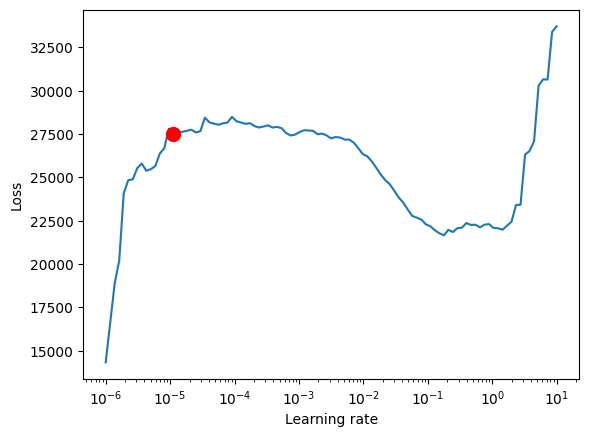

In [11]:
# find optimal learning rate
from pytorch_forecasting.tuning import Tuner

res = Tuner(trainer).lr_find(
    tft,
    train_dataloaders=train_dataloader,
    val_dataloaders=val_dataloader,
    max_lr=10.0,
    min_lr=1e-6,
)

print(f"suggested learning rate: {res.suggestion()}")
fig = res.plot(show=True, suggest=True)
fig.show()

# 0.03

Train model

In [12]:
# configure network and trainer
early_stop_callback = EarlyStopping(
    monitor="val_loss", min_delta=1e-4, patience=10, verbose=False, mode="min"
)
lr_logger = LearningRateMonitor()  # log the learning rate
logger = TensorBoardLogger("lightning_logs")  # logging results to a tensorboard

trainer = pl.Trainer(
    max_epochs=50,
    accelerator="cpu",
    enable_progress_bar=True,
    enable_model_summary=True,
    gradient_clip_val=0.1,
    limit_train_batches=50,  # comment in for training, running validation every 30 batches
    # fast_dev_run=True,  # comment in to check that networkor dataset has no serious bugs
    callbacks=[lr_logger, early_stop_callback],
    logger=logger,
)

tft = TemporalFusionTransformer.from_dataset(
    training,
    learning_rate=0.03,
    hidden_size=16,
    attention_head_size=2,
    dropout=0.1,
    hidden_continuous_size=8,
    loss=QuantileLoss(),
    log_interval=10,  # uncomment for learning rate finder and otherwise, e.g. to 10 for logging every 10 batches
    optimizer="ranger",
    reduce_on_plateau_patience=4,
)
print(f"Number of parameters in network: {tft.size() / 1e3:.1f}k")

INFO: GPU available: True (cuda), used: False
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: False
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Number of parameters in network: 20.9k


In [13]:
# fit network
trainer.fit(
    tft,
    train_dataloaders=train_dataloader,
    val_dataloaders=val_dataloader,
)

INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ QuantileLoss                    │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │     47 │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │    144 │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │  1.8 K │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │  3.9 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │  1.2 K │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │  2.2 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │  2.2 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │    544 │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │     32 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │  1.4 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │    808 │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │    576 │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │    576 │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │    119 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 20.9 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 20.9 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 330                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO: `Trainer.fit` stopped: `max_epochs=50` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=50` reached.


Hyperparameter tuning

In [14]:
import pickle

from pytorch_forecasting.models.temporal_fusion_transformer.tuning import optimize_hyperparameters

# create study
study = optimize_hyperparameters(
    train_dataloader,
    val_dataloader,
    model_path="optuna_test",
    n_trials=50,
    max_epochs=20,
    gradient_clip_val_range=(0.01, 1.0),
    hidden_size_range=(8, 128),
    hidden_continuous_size_range=(8, 128),
    attention_head_size_range=(1, 4),
    learning_rate_range=(0.001, 0.1),
    dropout_range=(0.1, 0.3),
    trainer_kwargs=dict(limit_train_batches=30),
    reduce_on_plateau_patience=4,
    use_learning_rate_finder=False,  # use Optuna to find ideal learning rate or use in-built learning rate finder
)

# save study results - also we can resume tuning at a later point in time
with open("test_study.pkl", "wb") as fout:
    pickle.dump(study, fout)

# show best hyperparameters
print(study.best_trial.params)

[I 2026-03-24 14:31:58,073] A new study created in memory with name: no-name-bddc86cc-67f2-43ad-ac86-ba8712547c97
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_D

{'gradient_clip_val': 0.40191601958271306, 'hidden_size': 45, 'dropout': 0.19444029091584902, 'hidden_continuous_size': 26, 'attention_head_size': 4, 'learning_rate': 0.009729088909123525}


Evaluate performance

In [15]:
# load the best model according to the validation loss
# (given that we use early stopping, this is not necessarily the last epoch)
best_model_path = trainer.checkpoint_callback.best_model_path
best_tft = TemporalFusionTransformer.load_from_checkpoint(best_model_path)

predict() 메서드는 반환값을 세밀하게 제어할 수 있게 한다.

In [16]:
# calculate mean absolute error on validation set
predictions = best_tft.predict(
    val_dataloader, return_y=True, trainer_kwargs=dict(accelerator="cpu")
)
MAE()(predictions.output, predictions.y)

INFO: GPU available: True (cuda), used: False
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: False
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytor

tensor(184755.6406)

In [17]:
# raw predictions are a dictionary from which all kind of information including quantiles can be extracted
raw_predictions = best_tft.predict(
    val_dataloader, mode="raw", return_x=True, trainer_kwargs=dict(accelerator="cpu")
)

num_predictions = raw_predictions.x["encoder_lengths"].size(0)

INFO: GPU available: True (cuda), used: False
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: False
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytor

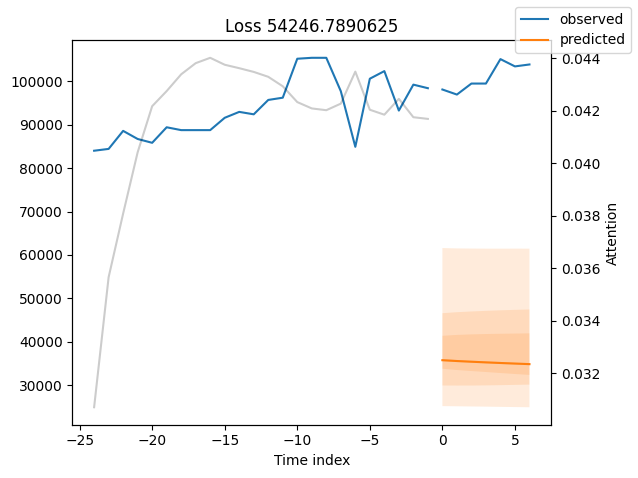

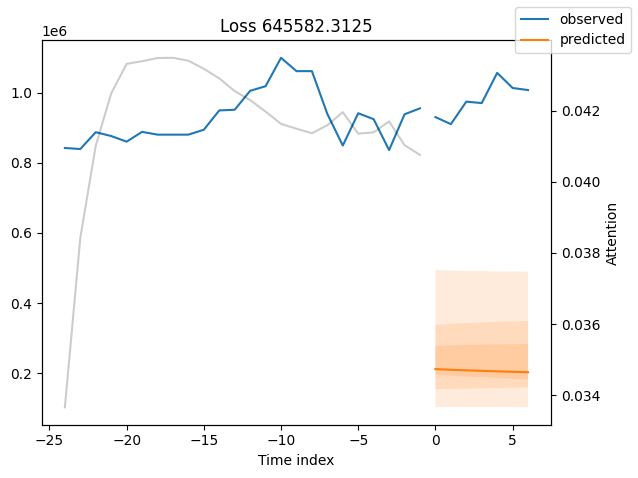

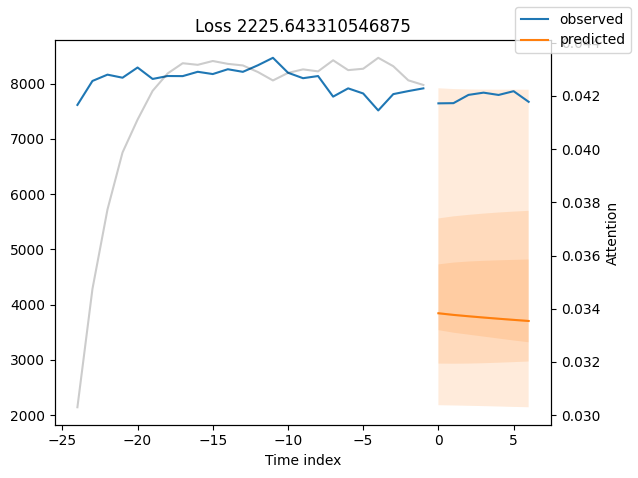

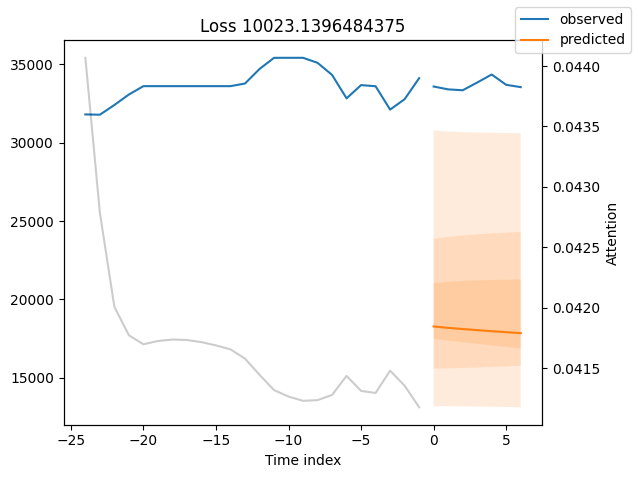

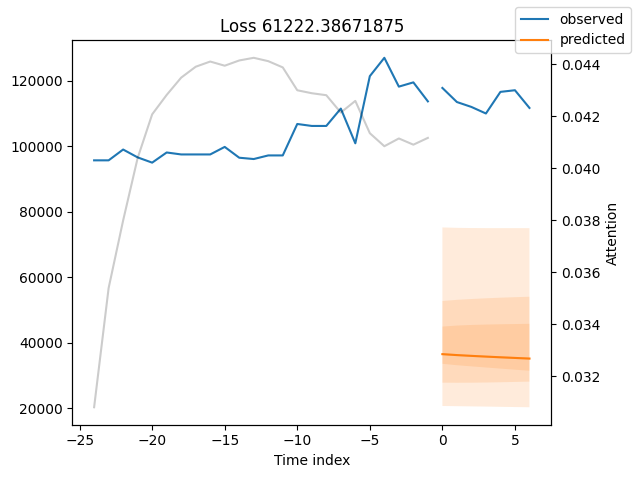

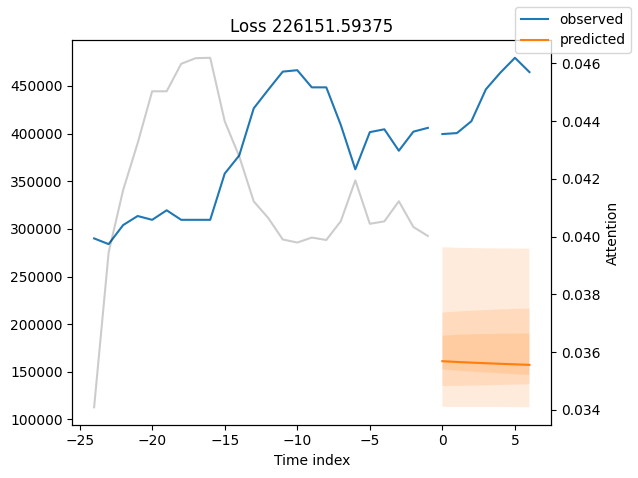

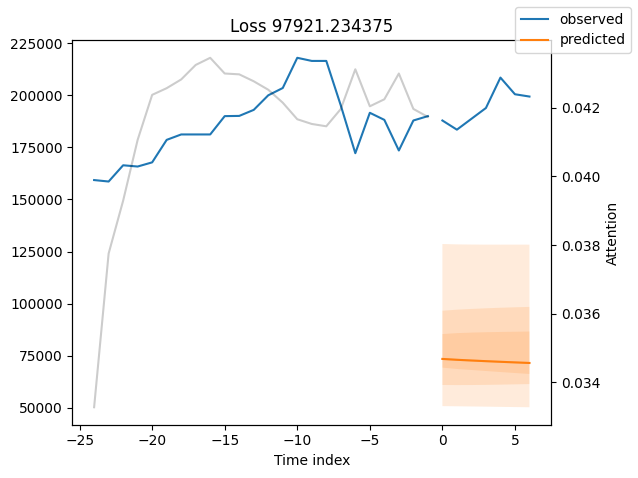

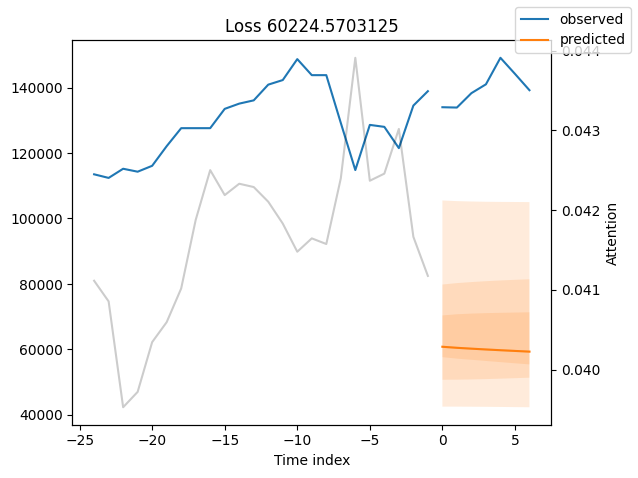

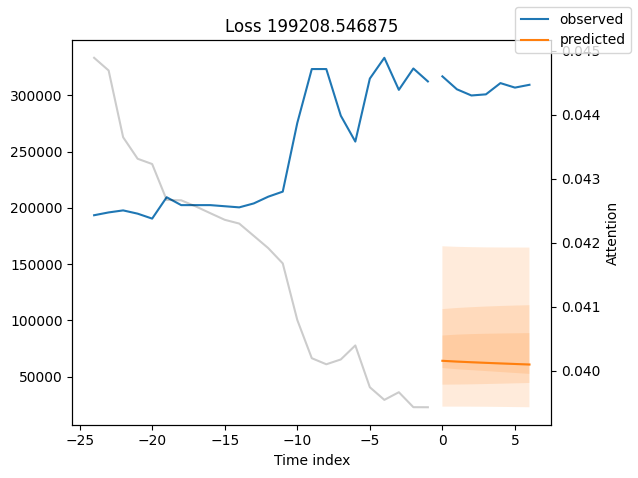

In [18]:
for idx in range(num_predictions):
    best_tft.plot_prediction(
        raw_predictions.x, raw_predictions.output, idx=idx, add_loss_to_title=True
    )

Worst performers

INFO: GPU available: True (cuda), used: False
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: False
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytor

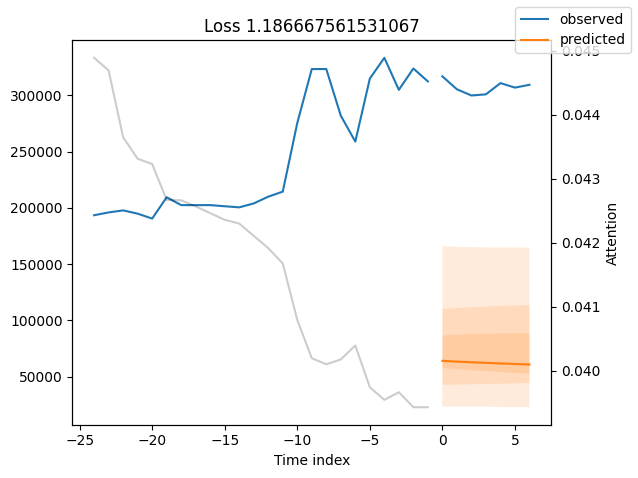

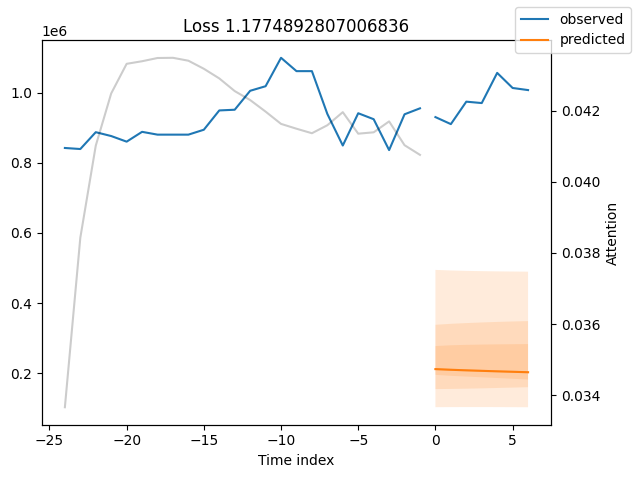

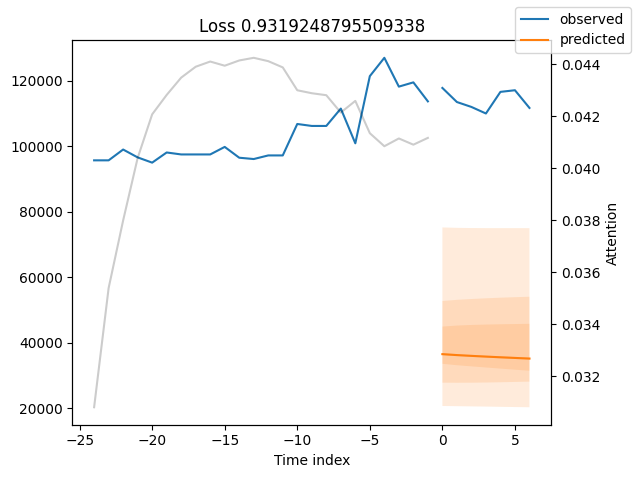

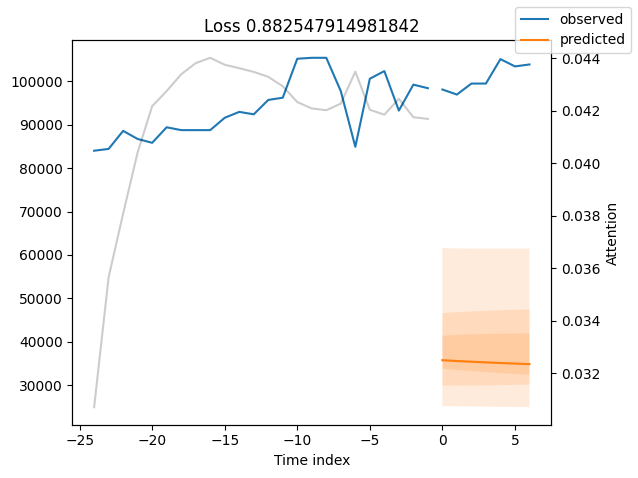

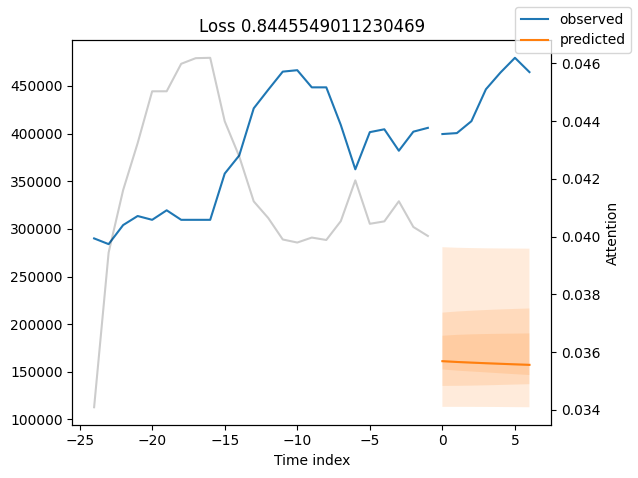

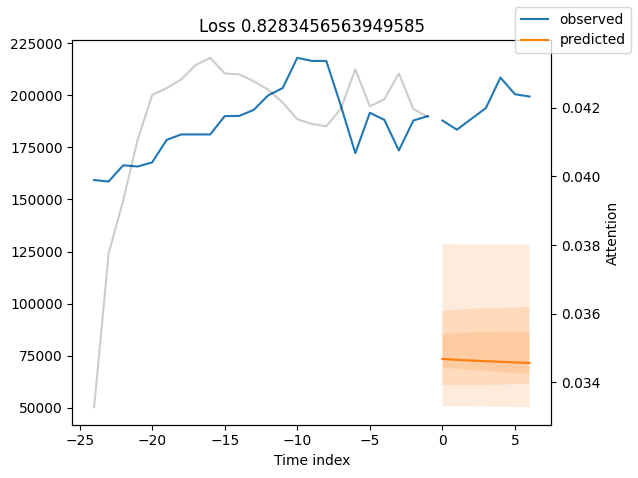

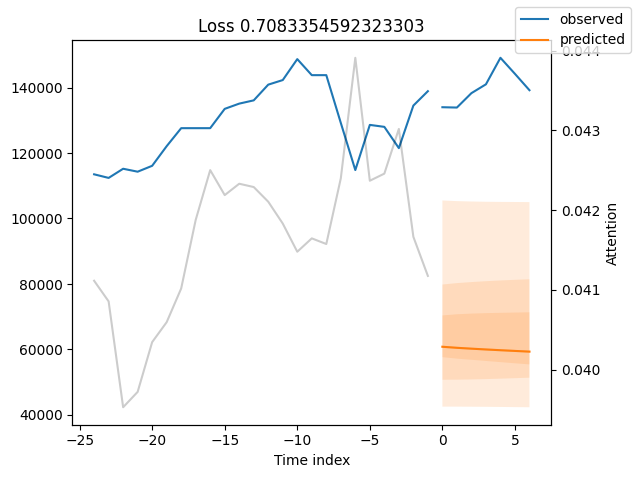

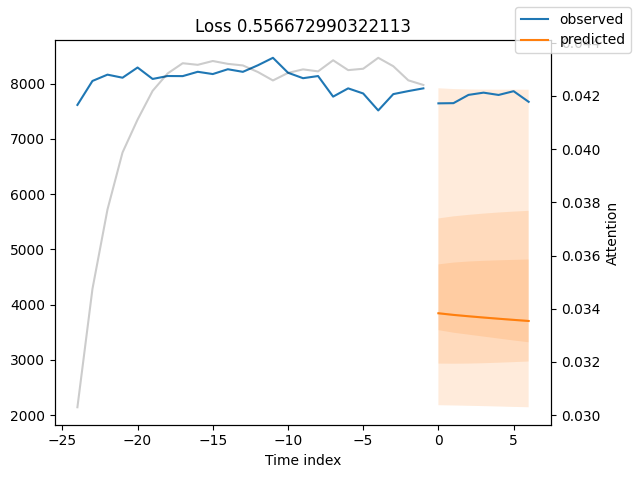

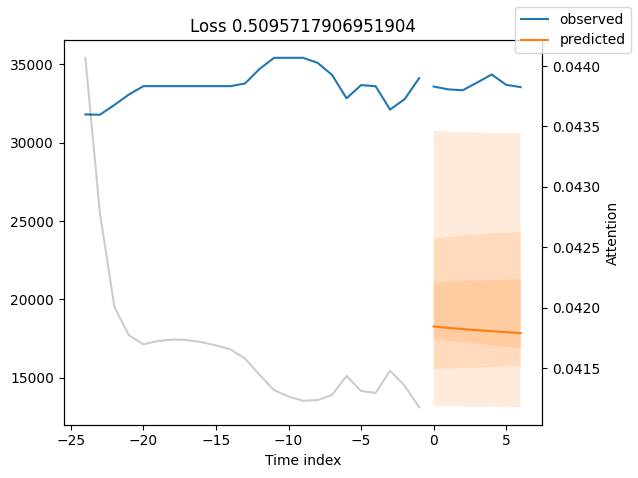

In [19]:
# calculate metric by which to display
predictions = best_tft.predict(
    val_dataloader, return_y=True, trainer_kwargs=dict(accelerator="cpu")
)
mean_losses = SMAPE(reduction="none").loss(predictions.output, predictions.y[0]).mean(1)
indices = mean_losses.argsort(descending=True)  # sort losses
for idx in range(num_predictions):
    best_tft.plot_prediction(
        raw_predictions.x,
        raw_predictions.output,
        idx=indices[idx],
        add_loss_to_title=SMAPE(quantiles=best_tft.loss.quantiles),
    )

Actuals vs predictions by variables

INFO: GPU available: True (cuda), used: False
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: False
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytor

{'encoder_length': <Figure size 1000x500 with 2 Axes>,
 'Close_center': <Figure size 1000x500 with 2 Axes>,
 'Close_scale': <Figure size 1000x500 with 2 Axes>,
 'time_idx': <Figure size 1000x500 with 2 Axes>,
 'relative_time_idx': <Figure size 1000x500 with 2 Axes>,
 'Open': <Figure size 1000x500 with 2 Axes>,
 'High': <Figure size 1000x500 with 2 Axes>,
 'Low': <Figure size 1000x500 with 2 Axes>,
 'Close': <Figure size 1000x500 with 2 Axes>,
 'Symbol': <Figure size 640x480 with 2 Axes>,
 'is_filled': <Figure size 640x480 with 2 Axes>}

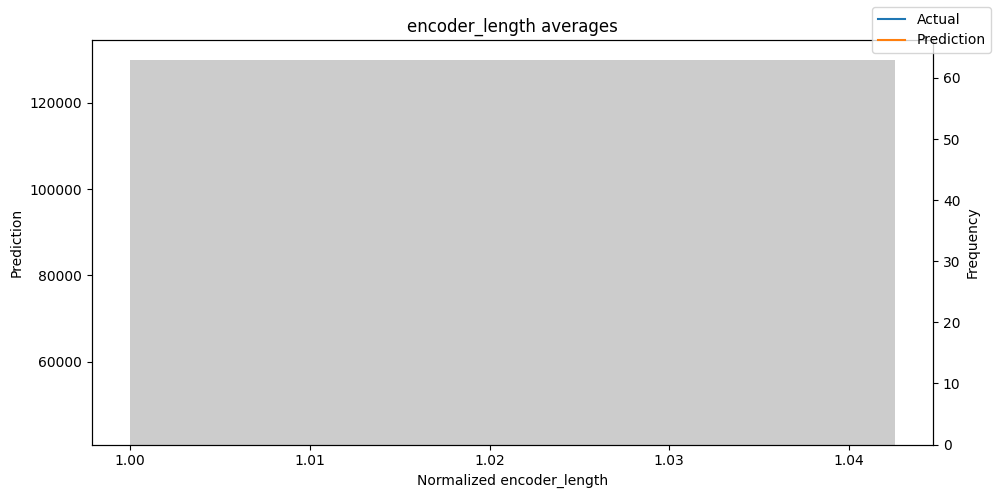

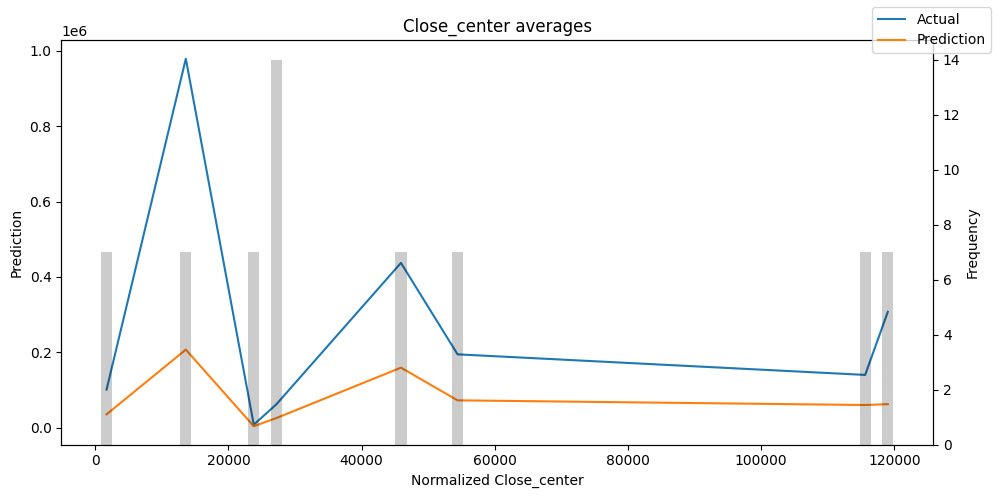

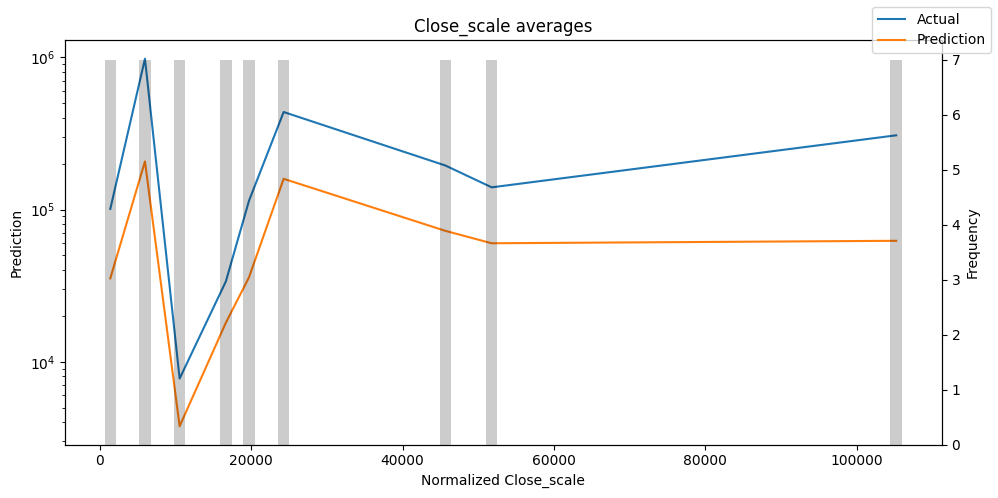

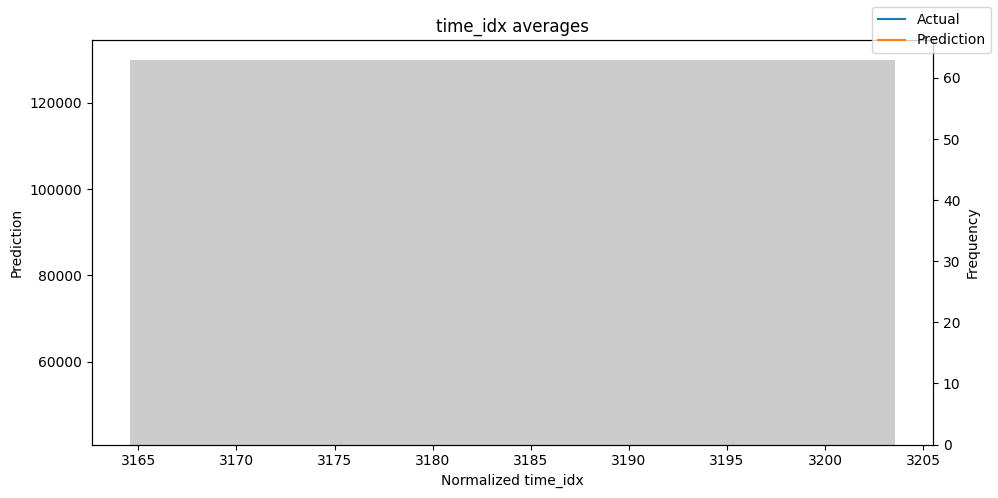

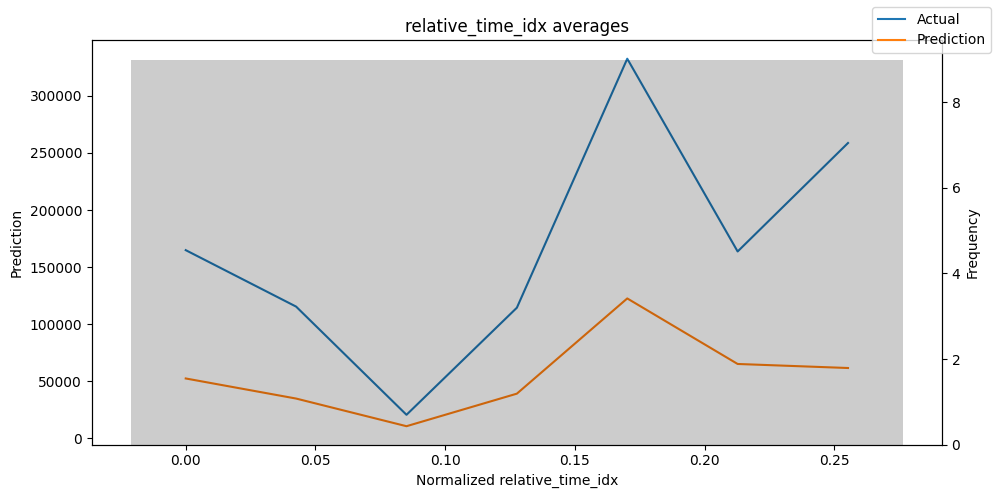

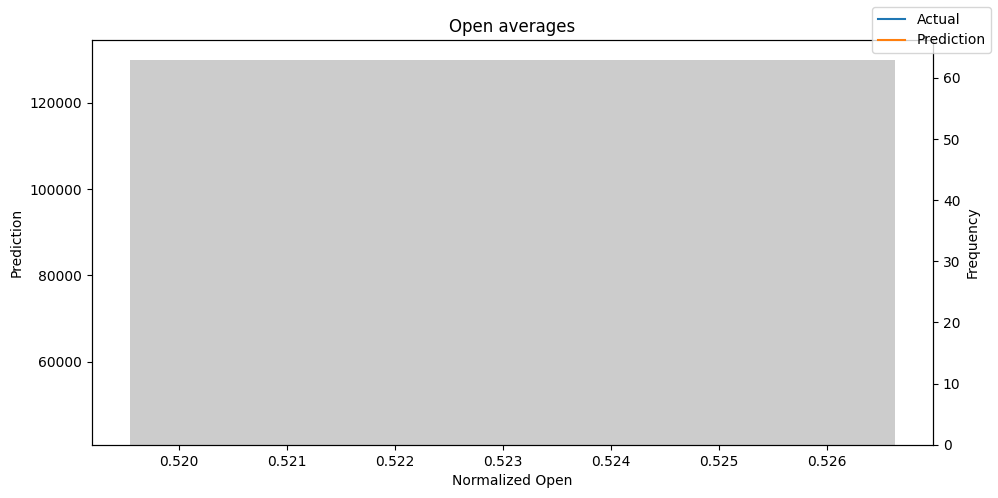

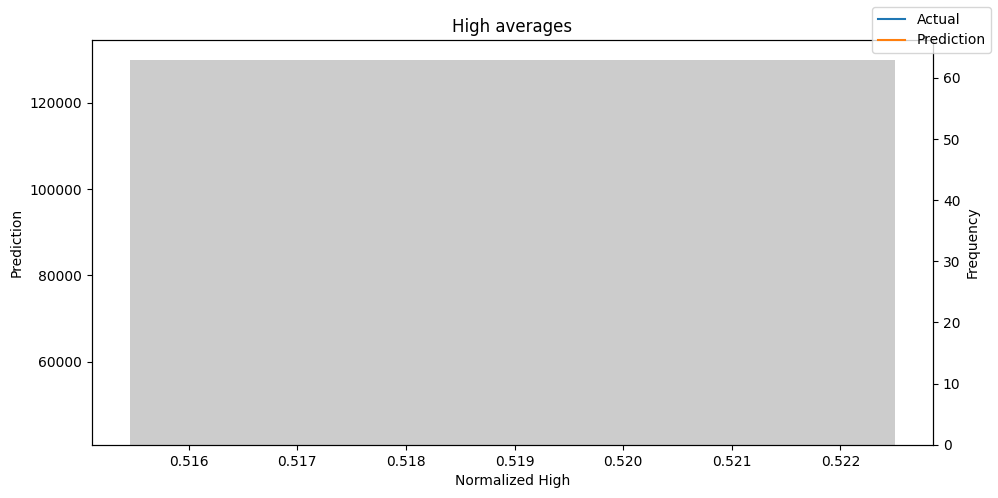

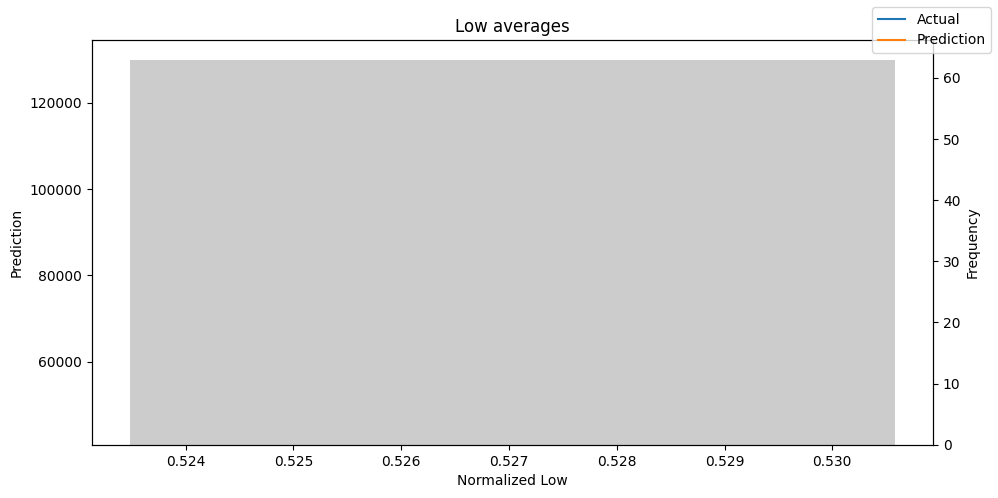

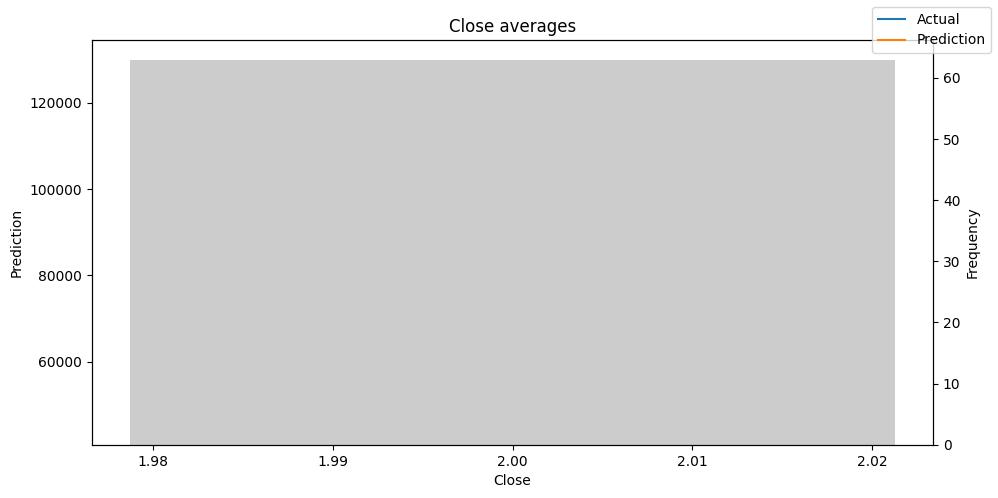

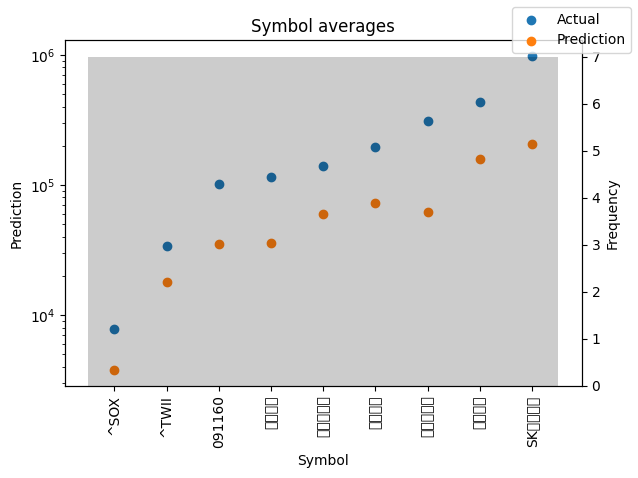

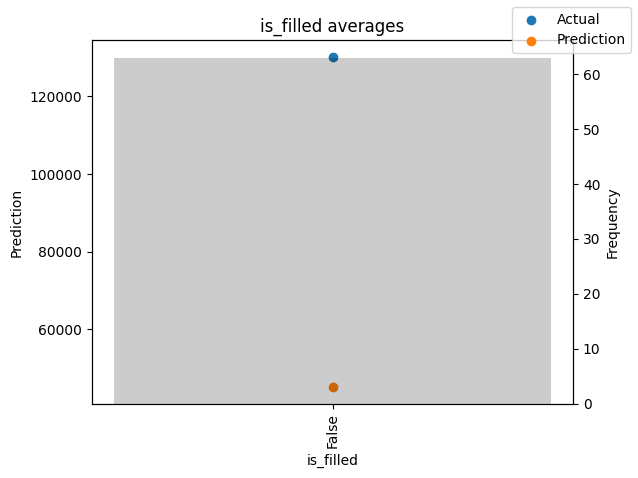

In [20]:
predictions = best_tft.predict(
    val_dataloader, return_x=True, trainer_kwargs=dict(accelerator="cpu")
)
predictions_vs_actuals = best_tft.calculate_prediction_actual_by_variable(
    predictions.x, predictions.output
)
best_tft.plot_prediction_actual_by_variable(predictions_vs_actuals)

Predict on selected data

In [21]:
# Filter the original combined_df for the target_symbol and the training cutoff
target_symbol_history = combined_df[
    (combined_df['Symbol'] == target_symbol) &
    (combined_df['time_idx'] <= training_cutoff)
]

# Create a TimeSeriesDataSet specifically for this target symbol from its history
# This will generate all possible prediction samples for this symbol within its history
# inheriting the parameters (encoder/decoder lengths, normalizers etc.) from the 'training' dataset
target_prediction_dataset = TimeSeriesDataSet.from_dataset(
    training,
    target_symbol_history,
    predict=True,  # Indicate this is for prediction
    stop_randomization=True # Ensures consistent sequence generation
)

# Predict using the newly created dataset
predictions = best_tft.predict(
    target_prediction_dataset.to_dataloader(train=False, batch_size=len(target_prediction_dataset)),
    mode="quantiles",
    trainer_kwargs=dict(accelerator="cpu"),
)

print(f"Predictions for {target_symbol} (first 5):")
print(predictions[:5]) # Corrected to directly access the tensor

INFO: GPU available: True (cuda), used: False
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: False
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytor

Predictions for SK하이닉스 (first 5):
tensor([[[103212.3594, 154771.0312, 195393.4062, 211762.8906, 277439.0625,
          338002.0000, 494457.7812],
         [103434.2422, 155233.5938, 192607.6875, 209849.8594, 279627.9375,
          340820.5000, 492846.7188],
         [103523.8750, 155970.4531, 190544.7812, 208279.8594, 280871.6250,
          342905.1250, 491743.3750],
         [103562.9922, 156904.5938, 188475.8906, 206815.3438, 281667.8438,
          344706.5625, 490874.5625],
         [103447.9141, 157953.6562, 186340.7812, 205438.7500, 282227.2812,
          346226.3750, 490280.1562],
         [103232.7031, 159061.4375, 184194.6250, 204124.8750, 282649.6875,
          347498.8125, 489847.0312],
         [103040.8594, 160158.4375, 182151.7344, 202848.2812, 283035.1875,
          348582.6875, 489383.6250]]])


In [22]:
# Check if target_symbol ('SK하이닉스') is present in the data used to create the training dataset
df_for_training = combined_df[combined_df.time_idx <= training_cutoff]
is_target_symbol_present = target_symbol in df_for_training['Symbol'].unique()

print(f"Is '{target_symbol}' present in the data filtered for training? {is_target_symbol_present}")

if is_target_symbol_present:
    # If present, check the number of rows for 'SK하이닉스' in the training data portion
    num_rows_for_target = df_for_training[df_for_training['Symbol'] == target_symbol].shape[0]
    print(f"Number of rows for '{target_symbol}' in training data: {num_rows_for_target}")
    print(f"Required min_encoder_length + min_prediction_length: {training.min_encoder_length + training.min_prediction_length}")
    print("If num_rows_for_target is less than the required length, it could be why no sequences are formed.")
else:
    print(f"'{target_symbol}' is NOT present in the data filtered for training. This is why no sub-sequences are found.")

Is 'SK하이닉스' present in the data filtered for training? True
Number of rows for 'SK하이닉스' in training data: 3173
Required min_encoder_length + min_prediction_length: 13
If num_rows_for_target is less than the required length, it could be why no sequences are formed.


INFO: GPU available: True (cuda), used: False
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: False
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytor

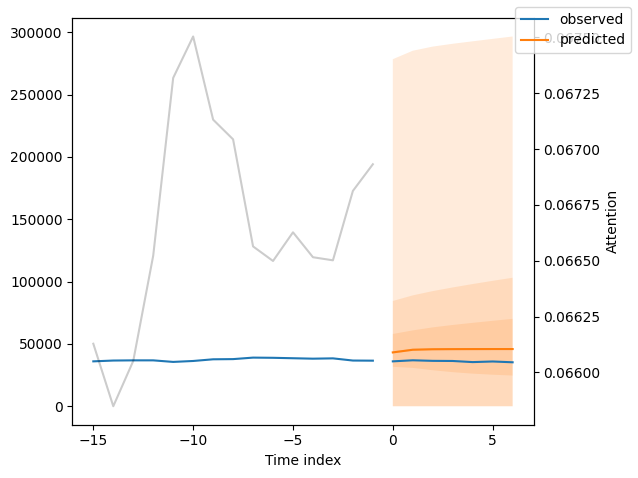

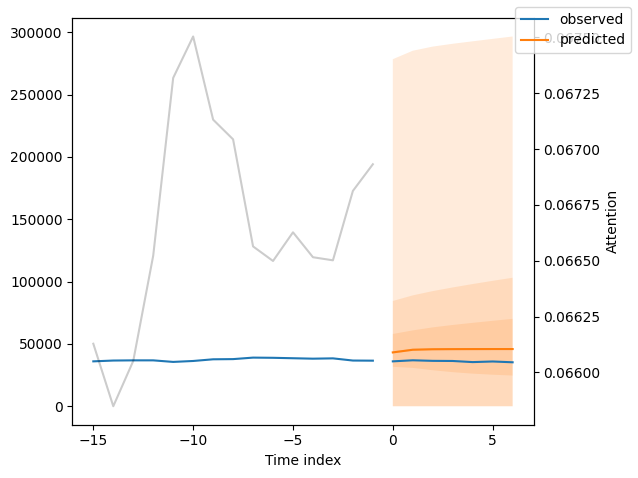

In [23]:
raw_prediction = best_tft.predict(
    training.filter(
        lambda x: (x.Symbol == target_symbol)
                  & (x.time_idx_first_prediction == 15)
    ),
    mode="raw",
    return_x=True,
    trainer_kwargs=dict(accelerator="cpu"),
)
best_tft.plot_prediction(raw_prediction.x, raw_prediction.output, idx=0)

Predict on new data

In [24]:
# select last 24 months from data (max_encoder_length is 24)
encoder_data = combined_df[combined_df['time_idx'] > combined_df['time_idx'].max() - max_encoder_length]

# select last known data point and create decoder data from it by repeating it and incrementing the month
# in a real world dataset, we should not just forward fill the covariates but specify them to account
# for changes in special days and prices (which you absolutely should do but we are too lazy here)
last_data = combined_df[combined_df['time_idx'] == combined_df['time_idx'].max()].copy()

decoder_rows = []
for i in range(1, max_prediction_length + 1):
    temp_df = last_data.copy()

    temp_df['Date'] = temp_df['Date'] + pd.Timedelta(days=i)
    temp_df['time_idx'] = temp_df['time_idx'] + i

    decoder_rows.append(temp_df)

decoder_data = pd.concat(decoder_rows, ignore_index=True)

new_prediction_data = pd.concat([encoder_data, decoder_data], ignore_index=True)

INFO: GPU available: True (cuda), used: False
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: False
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytor

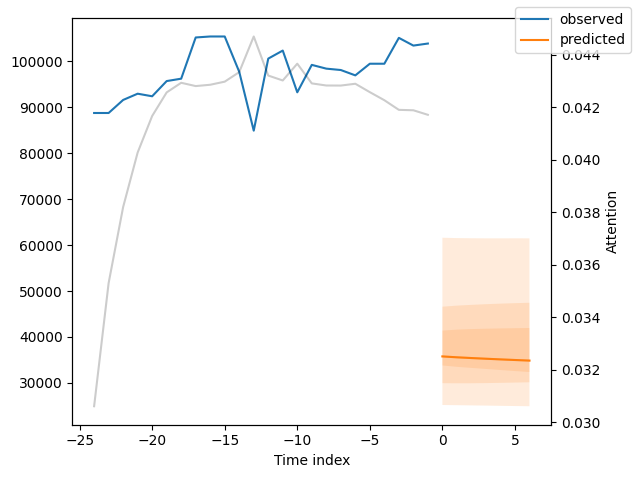

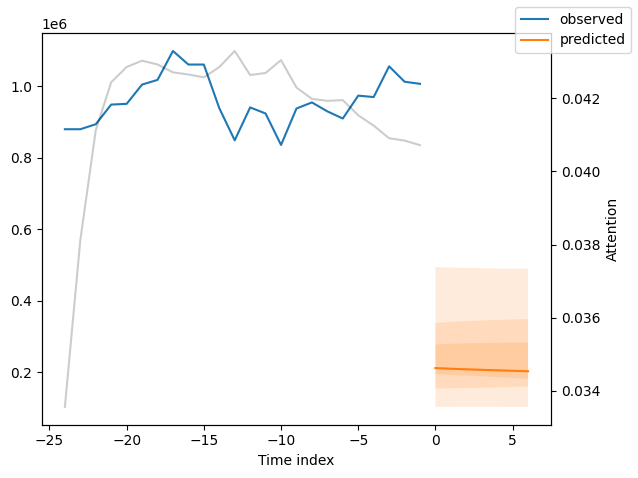

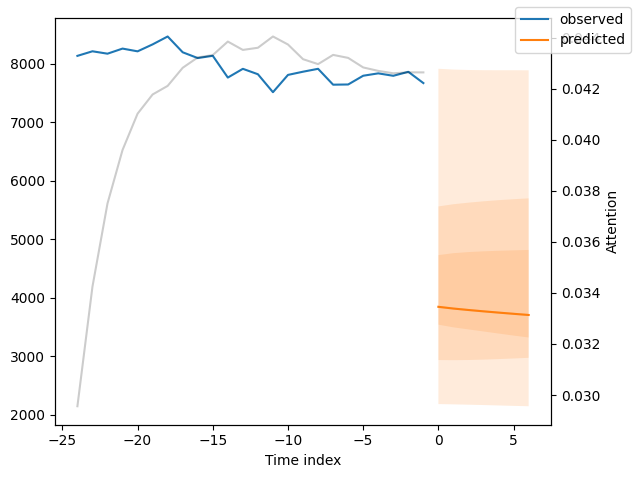

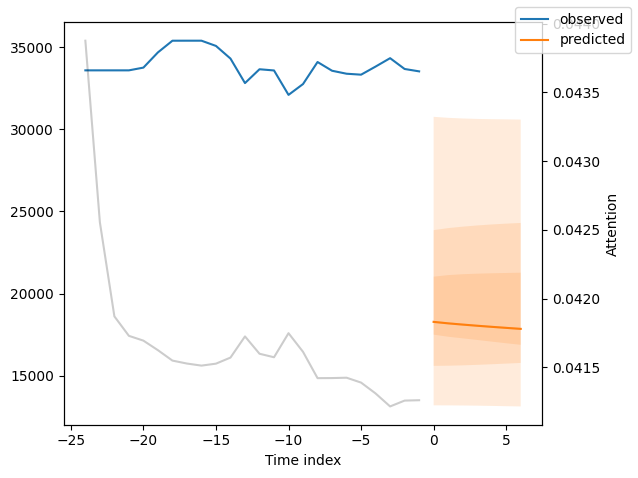

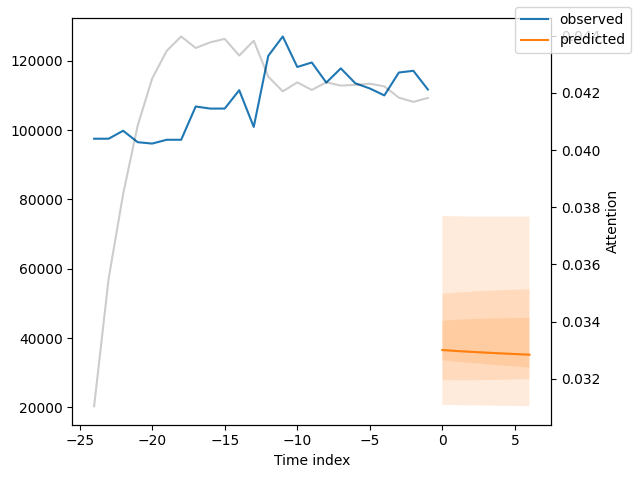

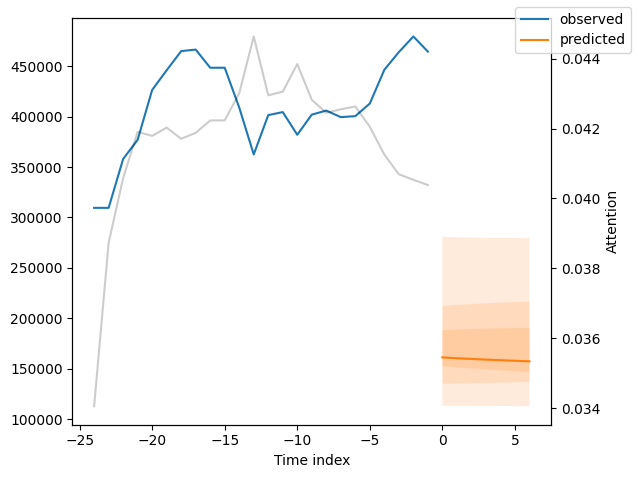

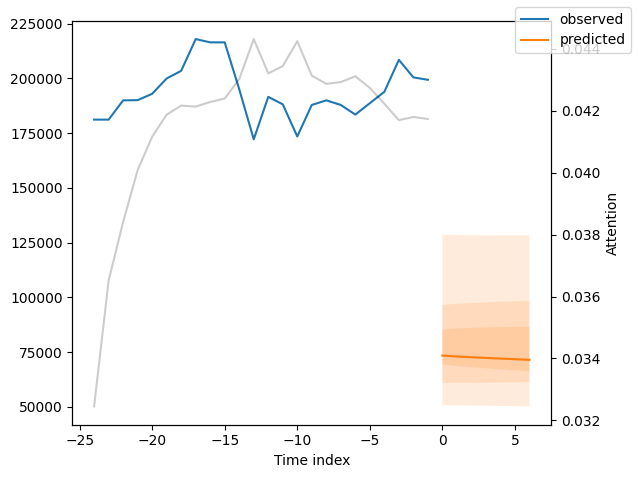

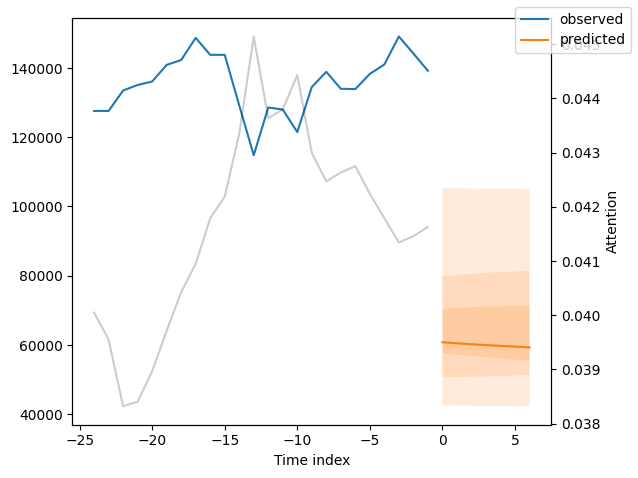

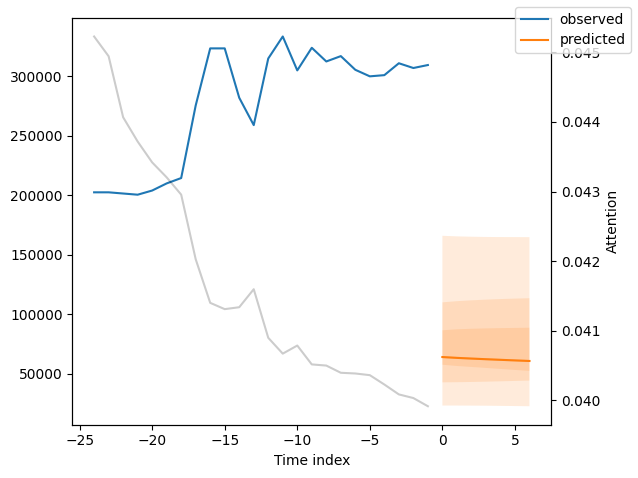

In [25]:
new_raw_predictions = best_tft.predict(
    new_prediction_data,
    mode="raw",
    return_x=True,
    trainer_kwargs=dict(accelerator="cpu"),
)

for idx in range(num_predictions):
    best_tft.plot_prediction(
        new_raw_predictions.x,
        new_raw_predictions.output,
        idx=idx,
        show_future_observed=False,
    )

Interpret model

Variable importances

{'attention': <Figure size 640x480 with 1 Axes>,
 'static_variables': <Figure size 700x300 with 1 Axes>,
 'encoder_variables': <Figure size 700x375 with 1 Axes>,
 'decoder_variables': <Figure size 700x250 with 1 Axes>}

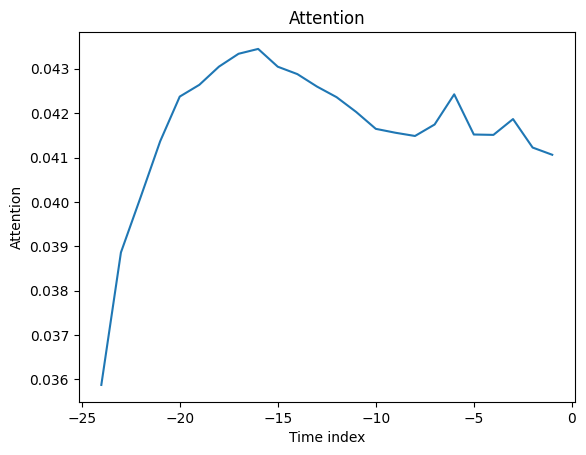

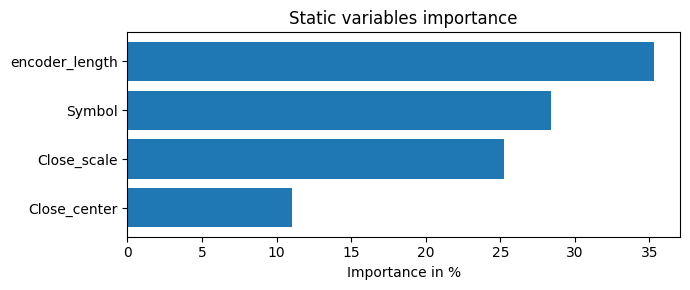

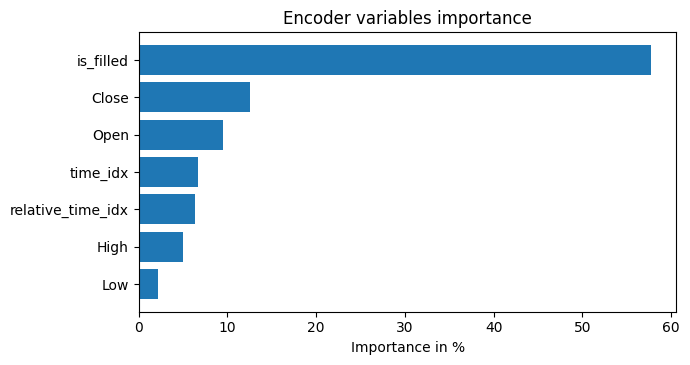

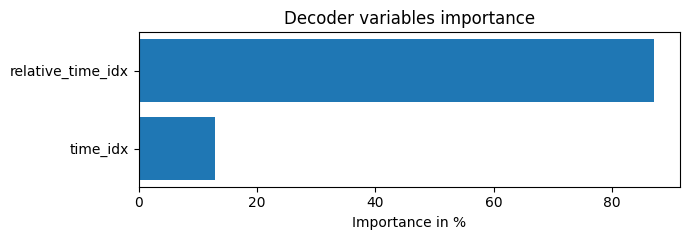

In [26]:
interpretation = best_tft.interpret_output(raw_predictions.output, reduction="sum")
best_tft.plot_interpretation(interpretation)

Partial dependency

In [27]:
import numpy as np

variables_to_test = ["Open", "High", "Low"]
test_values = np.linspace(10000, 100000, 30)

target_df = combined_df[combined_df['Symbol'] == target_symbol]

target_dataset = TimeSeriesDataSet.from_dataset(
    training, target_df, predict=True, stop_randomization=True
)

for var in variables_to_test:
    dependency = best_tft.predict_dependency(
        target_dataset,
        variable=var,
        values=test_values,
        show_progress_bar=False,
        mode="dataframe",
        trainer_kwargs=dict(accelerator="cpu"),
    )

INFO: GPU available: True (cuda), used: False
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: False
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytor

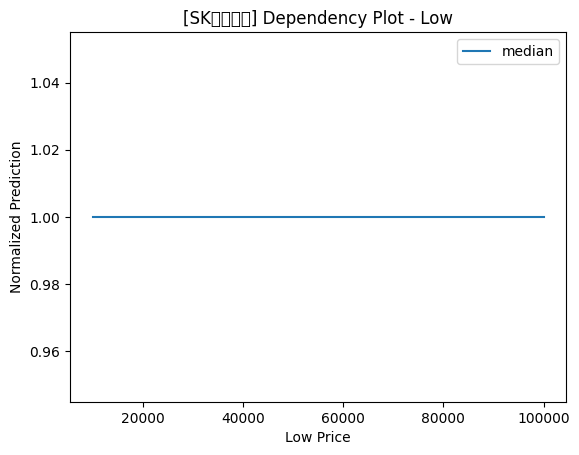

In [28]:
import matplotlib.pyplot as plt

# plotting median and 25% and 75% percentile
agg_dependency = dependency.groupby(var).normalized_prediction.agg(
    median="median", q25=lambda x: x.quantile(0.25), q75=lambda x: x.quantile(0.75)
)
ax = agg_dependency.plot(y="median", title=f"[{target_symbol}] Dependency Plot - {var}")
ax.fill_between(agg_dependency.index, agg_dependency.q25, agg_dependency.q75, alpha=0.3)
ax.set_xlabel(f"{var} Price")
ax.set_ylabel("Normalized Prediction")
plt.show()

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch

9개 종목, 7일 주가



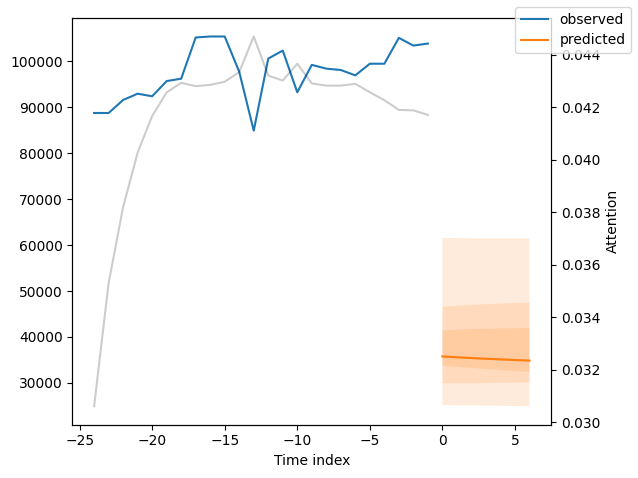

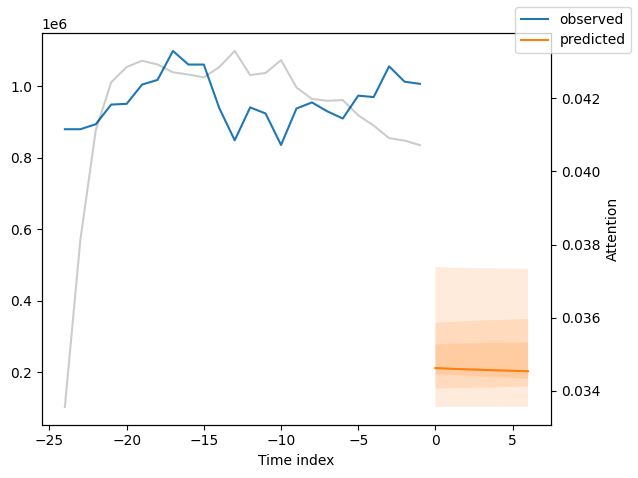

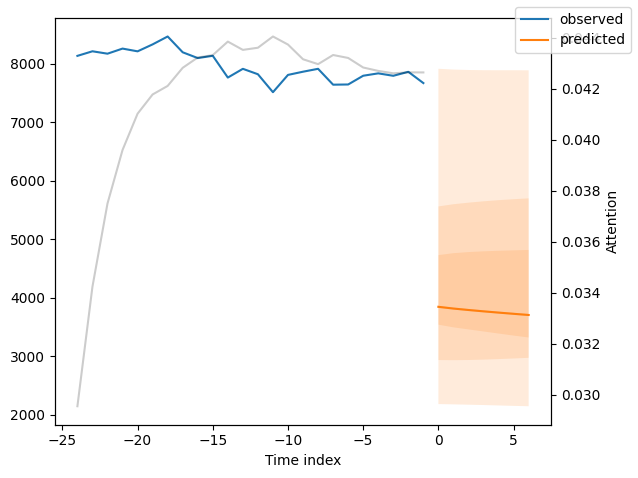

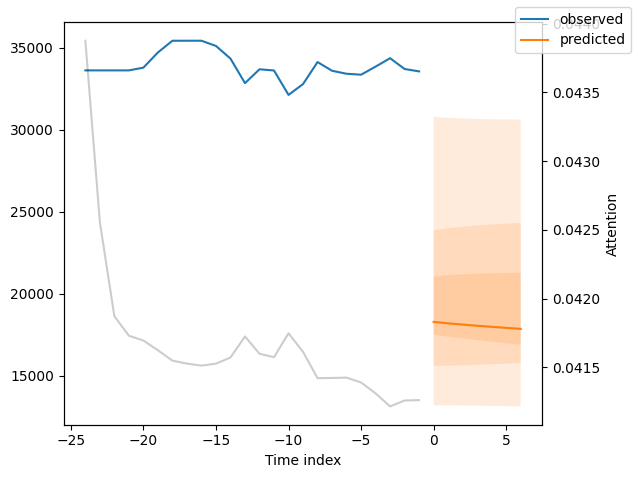

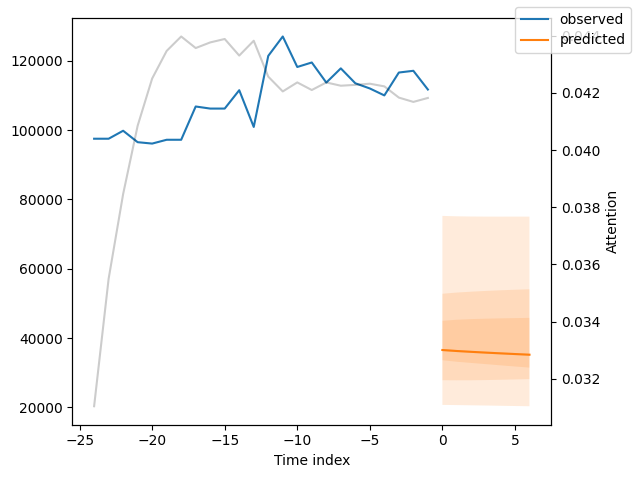

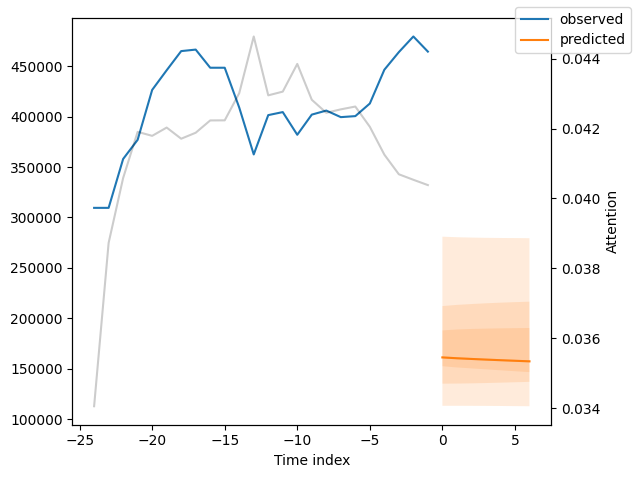

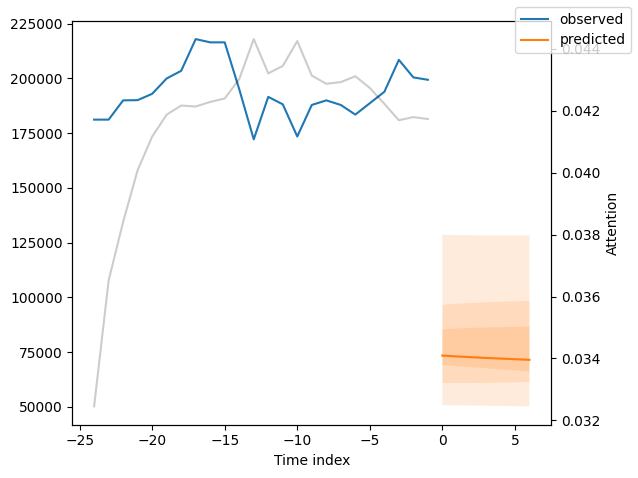

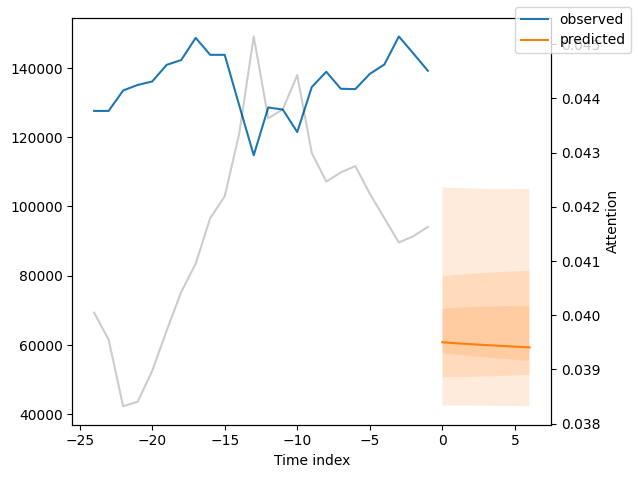

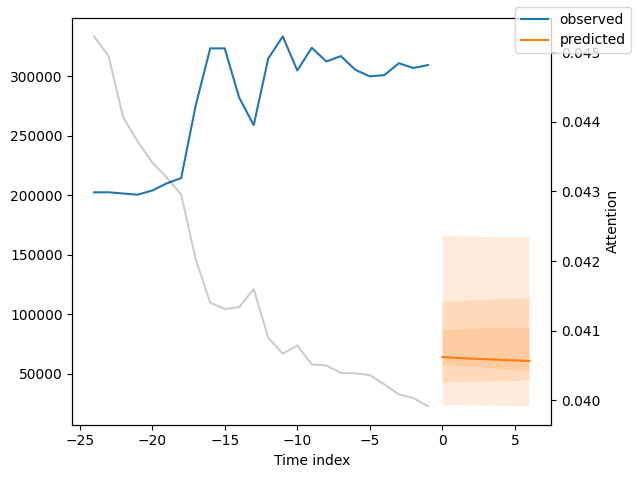

In [29]:
import matplotlib.pyplot as plt

predict_dataloader = training.from_dataset(
    training,
    new_prediction_data,
    predict=True,
    stop_randomization=True
).to_dataloader(train=False, batch_size=1)

future_predictions = best_tft.predict(predict_dataloader, mode="raw", return_x=True)

num_symbols = future_predictions.x["encoder_lengths"].size(0)
print(f"{num_symbols}개 종목, {max_prediction_length}일 주가\n")

for idx in range(num_symbols):
    fig = best_tft.plot_prediction(
        future_predictions.x,
        future_predictions.output,
        idx=idx,
        show_future_observed=False
    )
    plt.show()

In [32]:
# 로그 저장코드
!mkdir -p '/content/drive/MyDrive/Colab Notebooks/industries/backup'
!cp -r /content/lightning_logs '/content/drive/MyDrive/Colab Notebooks/industries/backup/'
!cp -r /content/optuna_test '/content/drive/MyDrive/Colab Notebooks/industries/backup/'